# Midterm Exercise 1 — $\ell_2^2$-regularized Binary Logistic Regression with $\rho$-Logistic Loss

**Author:** Lei Yang  
**Course:** (DATA 558 / 2026 Spring)

We implement, from scratch, the fast gradient algorithm with backtracking line search to minimize

$$F(\beta)=\frac{1}{n}\sum_{i=1}^{n}\frac{1}{\rho}\log\!\bigl(1+\exp(-\rho\,y_i\,x_i^\top\beta)\bigr)+\lambda\|\beta\|_2^{2}.$$


## (a) Gradient $\nabla F(\beta)$

Let $z_i = -\rho\,y_i\,x_i^{\top}\beta$ and $\sigma(u)=1/(1+e^{-u})$ be the sigmoid. Then

$$\nabla_\beta\!\left[\tfrac{1}{\rho}\log(1+e^{z_i})\right]
=\tfrac{1}{\rho}\,\sigma(z_i)\cdot\nabla z_i
=\tfrac{1}{\rho}\,\sigma(z_i)\cdot(-\rho\,y_i\,x_i)
=-y_i\,x_i\,\sigma\!\bigl(-\rho\,y_i\,x_i^{\top}\beta\bigr).$$

Adding the regularizer's contribution $\nabla(\lambda\|\beta\|^2)=2\lambda\beta$,

$$\boxed{\;\nabla F(\beta)= -\frac{1}{n}\,X^{\top}\!\bigl(y\odot\sigma(-\rho\,y\odot X\beta)\bigr) + 2\lambda\,\beta\;}$$

where $\odot$ is the elementwise product. We verify this gradient with a finite-difference check at the end of the notebook.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)

## (b) `traintestsplit`

Reproducible random 80/20 (or any `frac`) split using `numpy.random.default_rng(seed)`.

In [28]:
def traintestsplit(X, y, frac=0.8, seed=558):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.permutation(n)
    n_train = int(frac * n)
    train_idx, test_idx = idx[:n_train], idx[n_train:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

## (c) Algerian forest fire dataset — load & preprocess

Steps:
1. `pd.read_csv` with `skiprows=[0, 124, 125, 126, 170]`.
2. Strip whitespace from column names *and* string-typed cells (the `Classes` column has trailing spaces in the raw file).
3. Drop `day`, `month`, `year`.
4. Coerce remaining feature columns to numeric.
5. Map `Classes`: `fire` $\to +1$, `not fire` $\to -1$. Any row with another label is reported and dropped.
6. 80/20 train/test split.
7. Standardize features using **training** mean/std; apply same transform to test.

In [36]:
file = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
        '00547/Algerian_forest_fires_dataset_UPDATE.csv')
aff = pd.read_csv(file, skiprows=[0, 124, 125, 126, 170])

# 1. Trim column names
aff.columns = [c.strip() for c in aff.columns]

# 2. Drop date columns
aff = aff.drop(columns=['day', 'month', 'year'])

# 3. Trim whitespace inside string cells
for c in aff.select_dtypes(include='object').columns:
    aff[c] = aff[c].astype(str).str.strip()

# 4. Coerce features to numeric
feat_cols = [c for c in aff.columns if c != 'Classes']
for c in feat_cols:
    aff[c] = pd.to_numeric(aff[c], errors='coerce')

# 5. Encode +1 / -1
cls = aff['Classes'].str.lower().str.strip()
label_map = {'fire': 1, 'not fire': -1}
bad = aff.loc[~cls.isin(label_map), 'Classes'].unique()
if len(bad):
    print(f'Dropping rows with unrecognized Classes labels: {bad}')
aff = aff.loc[cls.isin(label_map)].copy()
y_all = cls.loc[aff.index].map(label_map).to_numpy(float)
X_df = aff[feat_cols].copy()

# Drop rows with any NaN feature (rare; from coercion)
keep = ~X_df.isna().any(axis=1)
if (~keep).any():
    print(f'Dropping {(~keep).sum()} rows with NaN feature values')
X_all = X_df.loc[keep].to_numpy(float)
y_all = y_all[keep.to_numpy()]

print(f'Cleaned dataset: {X_all.shape[0]} samples, {X_all.shape[1]} features')
print(f'Label balance: +1 (fire) = {(y_all==1).sum()}, -1 (not fire) = {(y_all==-1).sum()}')

# 6. 80/20 split (keep raw copies for part (f) re-split)
X_train_raw, y_train, X_test_raw, y_test = traintestsplit(X_all, y_all, frac=0.8, seed=558)

# 7. Standardize using training mean/std
mu  = X_train_raw.mean(axis=0)
sd  = X_train_raw.std(axis=0, ddof=0)
sd  = np.where(sd == 0, 1.0, sd)
X_train = (X_train_raw - mu) / sd
X_test  = (X_test_raw  - mu) / sd

d = X_train.shape[1]
print(f'Train: {X_train.shape}, Test: {X_test.shape}, d = {d}')

Cleaned dataset: 243 samples, 10 features
Label balance: +1 (fire) = 137, -1 (not fire) = 106
Train: (194, 10), Test: (49, 10), d = 10


## (d) `myrhologistic` — loss, gradient, line search, fast gradient

### $\rho$-logistic loss
Numerically stable form: $\log(1+e^{z}) = \mathrm{logaddexp}(0, z)$ avoids overflow for large $z$.

In [37]:
def rhologisticloss(beta, lam, rho, X, y):
    z = -rho * y * (X @ beta)
    return np.mean(np.logaddexp(0.0, z)) / rho + lam * np.dot(beta, beta)

### Gradient
$$\nabla F(\beta)= -\tfrac{1}{n}X^{\top}\!\bigl(y\odot\sigma(-\rho\,y\odot X\beta)\bigr)+2\lambda\beta.$$

Sigmoid is computed with the branch trick to avoid `exp` overflow.

In [38]:
def rhologisticgrad(beta, lam, rho, X, y):
    n = X.shape[0]
    s = -rho * y * (X @ beta)
    sig = np.where(s >= 0, 1.0 / (1.0 + np.exp(-s)),
                          np.exp(s) / (1.0 + np.exp(s)))
    return -(1.0 / n) * (X.T @ (y * sig)) + 2.0 * lam * beta

### Backtracking line search
Decrease step size $\eta$ by `decay_rate` until the Armijo condition
$F(\beta-\eta\nabla F(\beta))\le F(\beta)-c\,\eta\|\nabla F(\beta)\|^2$ holds.

In [50]:
def backtracking(beta, lam, rho, eta_init, decay_rate, prop_constant, X, y,
                 max_iter=100):
    eta = eta_init
    g = rhologisticgrad(beta, lam, rho, X, y)
    g2 = float(g @ g)
    f0 = rhologisticloss(beta, lam, rho, X, y)
    for _ in range(max_iter):
        if rhologisticloss(beta - eta * g, lam, rho, X, y) \
                <= f0 - prop_constant * eta * g2:
            return eta
        eta *= decay_rate
    return eta

### Fast gradient algorithm (two-sequence Nesterov form)

$$\beta_{t+1}=\theta_t-\eta_t\nabla F(\theta_t),\qquad
\theta_{t+1}=\beta_{t+1}+\frac{t}{t+3}(\beta_{t+1}-\beta_t).$$

Stop when $\|\nabla F(\theta_t)\|<\varepsilon$ (or max iterations reached). The function returns the final $\beta$ and the iterate history.

In [53]:
def fastgradalgo(beta_init, theta_init, lam, rho, eta_init, X, y, epsilon,
                 max_iter=1000, decay_rate=0.5, prop_constant=0.5,
                 record_history=True):
    beta  = beta_init.astype(float).copy()
    theta = theta_init.astype(float).copy()
    eta   = float(eta_init)
    hist  = [beta.copy()] if record_history else None
    for t in range(max_iter):
        g = rhologisticgrad(theta, lam, rho, X, y)
        if np.linalg.norm(g) < epsilon:
            break
        eta = backtracking(theta, lam, rho, eta, decay_rate, prop_constant, X, y)
        beta_new = theta - eta * g
        theta    = beta_new + (t / (t + 3.0)) * (beta_new - beta)
        beta     = beta_new
        if record_history:
            hist.append(beta.copy())
    return beta, hist

## (e) Train with $\rho=2$, $\varepsilon=10^{-3}$, $\lambda=1$

Helpers `getpreds` and `acc` first, then training and reported test misclassification.

In [68]:
def getpreds(beta, X):
    return np.where(X @ beta >= 0.0, 1, -1)

def acc(preds, truth):
    return float(np.mean(preds == truth))

In [69]:
rho     = 2.0
epsilon = 1e-3
lam_e   = 1.0

beta_e, _ = fastgradalgo(np.zeros(d), np.zeros(d), lam_e, rho,
                         eta_init=1.0, X=X_train, y=y_train,
                         epsilon=epsilon, max_iter=2000)

train_err_e = 1.0 - acc(getpreds(beta_e, X_train), y_train)
test_err_e  = 1.0 - acc(getpreds(beta_e, X_test),  y_test)

print(f'Part (e):  lam = 1, rho = 2, eps = 1e-3')
print(f'  Train misclassification error: {train_err_e:.4f}')
print(f'  Test  misclassification error: {test_err_e:.4f}')

Part (e):  lam = 1, rho = 2, eps = 1e-3
  Train misclassification error: 0.1289
  Test  misclassification error: 0.1224


## (f) Validation tuning of $\lambda$ + final fit

1. Re-split the original (non-standardized) training data 80/20 using `traintestsplit`.
2. Standardize the new training portion; apply the same transform to the validation portion.
3. Sweep $\lambda\in\{0.001, 0.01, 0.1, 1, 10, 50\}$, pick highest validation accuracy.
4. Refit on the full standardized training set with $\lambda^\star$, recording iterates.
5. Plot $F(\beta_t)$ and train/test misclassification vs iteration; report final test error.

In [70]:
# 1. Validation re-split (operates on the *raw* training features)
X_tr_raw, y_tr, X_val_raw, y_val = traintestsplit(
    X_train_raw, y_train, frac=0.8, seed=558)

# 2. Standardize using new-training mean/std
mu_tr = X_tr_raw.mean(axis=0)
sd_tr = X_tr_raw.std(axis=0, ddof=0)
sd_tr = np.where(sd_tr == 0, 1.0, sd_tr)
X_tr  = (X_tr_raw  - mu_tr) / sd_tr
X_val = (X_val_raw - mu_tr) / sd_tr

# 3. Grid search
lam_vals = [0.001, 0.01, 0.1, 1, 10, 50]
val_accs = []
for lv in lam_vals:
    bhat, _ = fastgradalgo(np.zeros(d), np.zeros(d), lv, rho,
                           eta_init=1.0, X=X_tr, y=y_tr,
                           epsilon=epsilon, max_iter=2000,
                           record_history=False)
    a = acc(getpreds(bhat, X_val), y_val)
    val_accs.append(a)
    print(f'  lam = {lv:<7}  val_acc = {a:.4f}')

best_lam = lam_vals[int(np.argmax(val_accs))]
print(f'\nBest lambda (by validation accuracy): {best_lam}')

  lam = 0.001    val_acc = 0.9487
  lam = 0.01     val_acc = 0.9487
  lam = 0.1      val_acc = 0.9231
  lam = 1        val_acc = 0.8718
  lam = 10       val_acc = 0.8718
  lam = 50       val_acc = 0.8718

Best lambda (by validation accuracy): 0.001


In [71]:
# 4. Refit on full standardized training data, record history
beta_f, hist_f = fastgradalgo(np.zeros(d), np.zeros(d), best_lam, rho,
                              eta_init=1.0, X=X_train, y=y_train,
                              epsilon=epsilon, max_iter=2000)

obj_curve  = [rhologisticloss(b, best_lam, rho, X_train, y_train) for b in hist_f]
trn_err    = [1.0 - acc(getpreds(b, X_train), y_train) for b in hist_f]
tst_err    = [1.0 - acc(getpreds(b, X_test),  y_test)  for b in hist_f]

print(f'Iterations run: {len(hist_f) - 1}')
print(f'Final test misclassification error (lam = {best_lam}): {tst_err[-1]:.4f}')

Iterations run: 161
Final test misclassification error (lam = 0.001): 0.0612


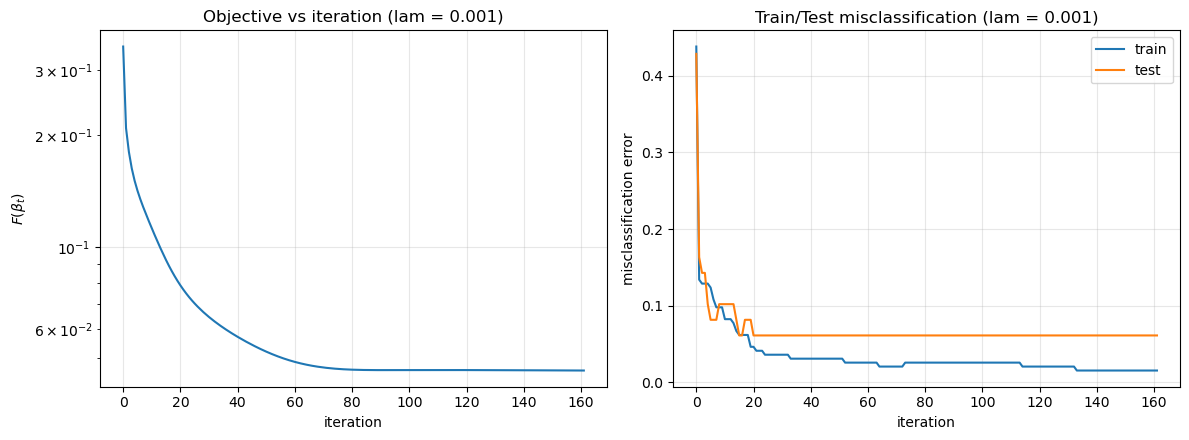

In [72]:
# 5. Plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(obj_curve)
ax[0].set_xlabel('iteration')
ax[0].set_ylabel(r'$F(\beta_t)$')
ax[0].set_title(f'Objective vs iteration (lam = {best_lam})')
ax[0].set_yscale('log')
ax[0].grid(alpha=0.3)

ax[1].plot(trn_err, label='train')
ax[1].plot(tst_err, label='test')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('misclassification error')
ax[1].set_title(f'Train/Test misclassification (lam = {best_lam})')
ax[1].grid(alpha=0.3)
ax[1].legend()

fig.tight_layout()
plt.show()

## Verification — finite-difference gradient check

A central-difference numerical gradient should agree with `rhologisticgrad` to high precision.

In [75]:
def finite_diff_grad(f, beta, h=1e-6):
    g = np.zeros_like(beta)
    for i in range(beta.size):
        e = np.zeros_like(beta); e[i] = h
        g[i] = (f(beta + e) - f(beta - e)) / (2 * h)
    return g

rng = np.random.default_rng(0)
beta_chk = rng.standard_normal(d)
g_an = rhologisticgrad(beta_chk, lam=0.5, rho=2.0, X=X_train, y=y_train)
g_nm = finite_diff_grad(
    lambda b: rhologisticloss(b, lam=0.5, rho=2.0, X=X_train, y=y_train),
    beta_chk)
rel_err = np.linalg.norm(g_an - g_nm) / (np.linalg.norm(g_an) + np.linalg.norm(g_nm) + 1e-12)
print(f'Gradient check relative error: {rel_err:.3e}')
assert rel_err < 1e-6, 'gradient mismatch'

Gradient check relative error: 6.448e-11


## Comments

- **Implementation choices.** The loss uses `np.logaddexp(0, z)` and the gradient uses the branch-stable form of the sigmoid, so both behave well even for large $|z|$. Backtracking restarts from the previous step size, which lets $\eta$ grow back up if the loss landscape becomes flatter.
- **Stopping criterion.** We stop on $\|\nabla F(\theta_t)\|<\varepsilon$ rather than $\|\nabla F(\beta_t)\|$ because the gradient is already evaluated at $\theta_t$ inside the loop — checking it costs nothing extra and is a valid criterion for the two-sequence form.
- **Standardization.** We always standardize using the *training* mean/std and apply that transform to validation/test, which prevents leakage of test-set statistics into model selection.
- **Reproducibility.** The same `seed=558` is used for the outer 80/20 split and the inner train/validation split, as suggested by the prompt.